# RideIQ – Intelligent Demand Forecasting for Smart Mobility

### Machine Learning-based ride demand forecasting and analytics system for smart transportation using predictive modeling and business intelligence.

## Project Overview

RideIQ is a machine learning-based analytics system that forecasts taxi ride demand using historical booking data. The project performs data preprocessing, feature engineering, exploratory data analysis, and predictive modeling to generate actionable insights for fleet optimization and operational planning.

## Technology Stack

- **Programming Language:** Python
- **Machine Learning:** Scikit-learn (Random Forest Regressor)
- **Data Processing:** Pandas, NumPy
- **Visualization:** Matplotlib
- **Geospatial Mapping:** Folium

## Workflow

1. Load and validate ride booking dataset
2. Perform data preprocessing and cleaning
3. Engineer temporal features for prediction
4. Analyze ride patterns and customer behavior
5. Train Random Forest demand forecasting model
6. Evaluate model performance
7. Generate business insights and visualizations

In [72]:
# ==========================================================
# Configuration
# Specify the input dataset before running the notebook.
# ==========================================================

CSV_FILE = "data/ncr_ride_bookings.csv"

# ==========================================================
# Import Required Libraries
# ==========================================================

import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================================
# Initial Setup
# ==========================================================

warnings.filterwarnings("ignore")
np.random.seed(42)

os.makedirs("outputs", exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "axes.axisbelow": True
})

# Color Palette
COLORS = {
    "blue": "#378ADD",
    "green": "#1D9E75",
    "red": "#D85A30",
    "orange": "#EF9F27",
    "purple": "#7F77DD",
    "gray": "#888780",
    "light_blue": "#B5D4F4",
    "light_green": "#9FE1CB"
}

PALETTE = [
    COLORS["blue"],
    COLORS["green"],
    COLORS["orange"],
    COLORS["red"],
    COLORS["purple"],
    COLORS["gray"],
    "#D4537E"
]

print("Environment setup completed successfully.")

Environment setup completed successfully.


In [73]:
# ==========================================================
# Data Loading & Preprocessing
# ==========================================================

raw = pd.read_csv(CSV_FILE, low_memory=False)
print(f"Loaded: {raw.shape[0]:,} rows × {raw.shape[1]} columns")

df = pd.DataFrame()

# Extract Date & Time Features
if 'Date' in raw.columns and 'Time' in raw.columns:
    raw['_dt'] = pd.to_datetime(raw['Date'].astype(str) + ' ' + raw['Time'].astype(str), errors='coerce')
else:
    dt_c = next((c for c in raw.columns if any(k in c.lower() for k in ['date', 'time', 'pickup'])), None)
    raw['_dt'] = pd.to_datetime(raw[dt_c], errors='coerce') if dt_c else pd.NaT

df['hour'] = raw['_dt'].dt.hour.fillna(12).astype(int)
df['day_of_week'] = raw['_dt'].dt.dayofweek.fillna(0).astype(int)
df['month'] = raw['_dt'].dt.month.fillna(6).astype(int)

# Process Fare Information
fc = next((c for c in raw.columns if any(k in c.lower() for k in ['booking value', 'fare', 'amount', 'price', 'earning'])), None)
df['fare'] = pd.to_numeric(raw[fc], errors='coerce').fillna(0) if fc else 150.0

# Process Ride Distance
dc = next((c for c in raw.columns if any(k in c.lower() for k in ['ride distance', 'dist', 'km', 'mile'])), None)
df['distance_km'] = pd.to_numeric(raw[dc], errors='coerce').abs().fillna(0) if dc else 10.0

# Booking Status
sc = next((c for c in raw.columns if 'booking status' in c.lower() or c.lower() == 'status'), None)
df['status'] = raw[sc].fillna('Unknown') if sc else 'Completed'
df['is_completed'] = (df['status'] == 'Completed').astype(int)

# Vehicle Type & Payment Method
vc = next((c for c in raw.columns if 'vehicle type' in c.lower()), None)
pc = next((c for c in raw.columns if 'payment' in c.lower()), None)

df['vehicle'] = raw[vc].fillna('Unknown') if vc else 'Unknown'
df['payment'] = raw[pc].fillna('Unknown') if pc else 'Unknown'

# Customer & Driver Ratings
dr_c = next((c for c in raw.columns if 'driver rating' in c.lower()), None)
cr_c = next((c for c in raw.columns if 'customer rating' in c.lower()), None)

df['driver_rating'] = pd.to_numeric(raw[dr_c], errors='coerce') if dr_c else np.nan
df['customer_rating'] = pd.to_numeric(raw[cr_c], errors='coerce') if cr_c else np.nan

# Waiting Time Metrics
vt_c = next((c for c in raw.columns if 'vtat' in c.lower()), None)
ct_c = next((c for c in raw.columns if 'ctat' in c.lower()), None)

df['vtat'] = pd.to_numeric(raw[vt_c], errors='coerce') if vt_c else np.nan
df['ctat'] = pd.to_numeric(raw[ct_c], errors='coerce') if ct_c else np.nan

# Cancellation Reasons
cc_c = next((c for c in raw.columns if 'reason' in c.lower() and 'customer' in c.lower()), None)
dc_c = next((c for c in raw.columns if 'reason' in c.lower() and 'driver' in c.lower()), None)

df['cancel_cust'] = raw[cc_c].fillna('None') if cc_c else 'None'
df['cancel_drv'] = raw[dc_c].fillna('None') if dc_c else 'None'

# Pickup Location
pu_c = next((c for c in raw.columns if 'pickup' in c.lower() and 'location' in c.lower()), None)
df['pickup'] = raw[pu_c].fillna('Unknown') if pu_c else 'Unknown'

# Detect City from Pickup Locations
top_places = ' '.join(df['pickup'].value_counts().head(30).index).lower()

NCR_KW = ['gurgaon', 'noida', 'dwarka', 'connaught', 'rohini', 'khandsa',
          'barakhamba', 'badarpur', 'palam', 'inderlok', 'aiims',
          'pragati', 'mehrauli']

PUNE_KW = ['hinjewadi', 'kothrud', 'baner', 'magarpatta', 'koregaon',
           'hadapsar', 'wakad', 'deccan', 'viman', 'pimpri', 'aundh']

MUM_KW = ['andheri', 'bandra', 'dadar', 'borivali', 'kurla',
          'thane', 'worli', 'powai', 'malad', 'goregaon']

scores = {
    'NCR (Delhi)': sum(1 for k in NCR_KW if k in top_places),
    'Pune': sum(1 for k in PUNE_KW if k in top_places),
    'Mumbai': sum(1 for k in MUM_KW if k in top_places)
}

CITY = max(scores, key=scores.get) if max(scores.values()) > 0 else 'City'

# Feature Engineering
df = df[(df['fare'] > 0) | (df['is_completed'] == 0)].reset_index(drop=True)

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_rush_am'] = ((df['hour'] >= 8) & (df['hour'] <= 10)).astype(int)
df['is_rush_pm'] = ((df['hour'] >= 17) & (df['hour'] <= 20)).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
df['is_monsoon'] = ((df['month'] >= 6) & (df['month'] <= 9)).astype(int)

hv = df.groupby('hour')['fare'].transform('count')
df['demand'] = (hv / hv.max() * 150 + 10).clip(5, 200).astype(int)

df['is_pooled'] = (
    (df['demand'] > 55) &
    (df['distance_km'].between(1, 15)) &
    (df['is_completed'] == 1)
).astype(int)

df['savings'] = (df['fare'] * 0.38).round(2)

completed = df[df['is_completed'] == 1].copy()

print(f"\nDetected City       : {CITY}")
print(f"Processed Records   : {len(df):,}")
print(f"Completed Rides     : {len(completed):,} ({len(completed)/len(df)*100:.1f}%)")
print(f"Average Fare        : ₹{completed['fare'].mean():.0f}")
print(f"Estimated Pool Rate : {df['is_pooled'].mean()*100:.1f}%")

Loaded: 150,000 rows × 21 columns

Detected City       : NCR (Delhi)
Processed Records   : 150,000
Completed Rides     : 93,000 (62.0%)
Average Fare        : ₹508
Estimated Pool Rate : 15.4%


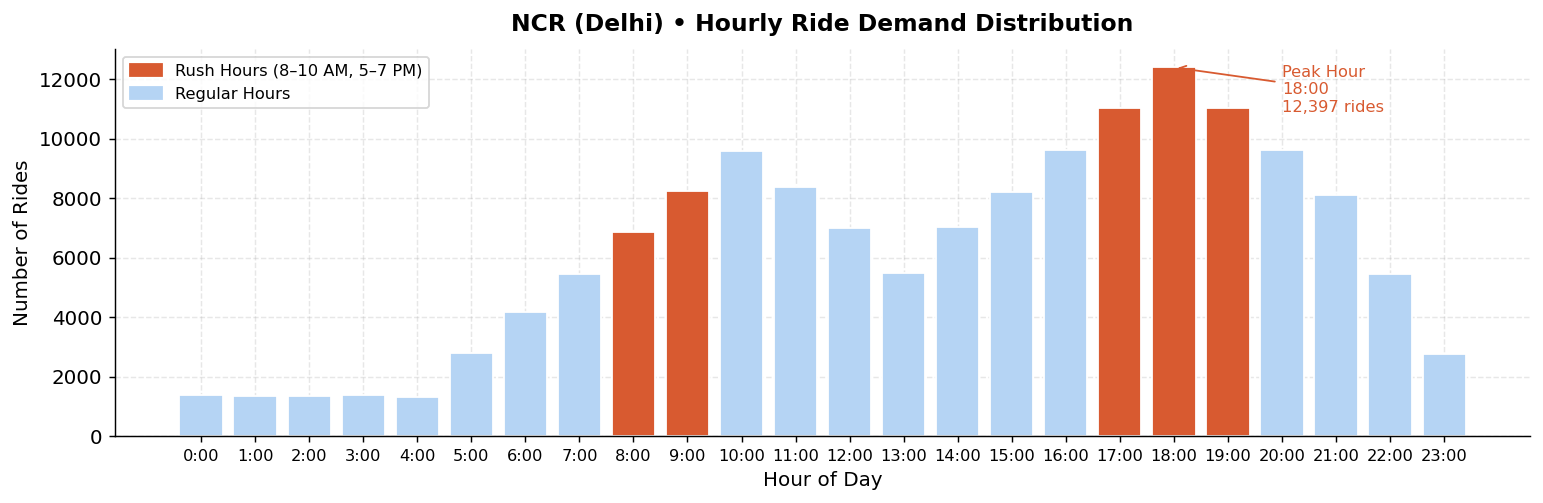

✓ Hourly demand chart saved successfully.


In [74]:
# ==========================================================
# Hourly Ride Demand Analysis
# Visualizes ride demand across different hours of the day.
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 4))

hourly = df.groupby('hour').size()

bar_colors = [
    COLORS["red"] if h in [8, 9, 17, 18, 19]
    else COLORS["light_blue"]
    for h in hourly.index
]

ax.bar(
    hourly.index,
    hourly.values,
    color=bar_colors,
    edgecolor="white",
    width=0.8
)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h}:00" for h in range(24)], fontsize=9)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Rides")

ax.set_title(
    f"{CITY} • Hourly Ride Demand Distribution",
    fontsize=13,
    fontweight="bold",
    pad=10
)

peak_hour = hourly.idxmax()

ax.annotate(
    f"Peak Hour\n{peak_hour}:00\n{hourly[peak_hour]:,} rides",
    xy=(peak_hour, hourly[peak_hour]),
    xytext=(peak_hour + 2, hourly[peak_hour] * 0.88),
    arrowprops=dict(
        arrowstyle="->",
        color=COLORS["red"]
    ),
    fontsize=9,
    color=COLORS["red"]
)

ax.legend(
    handles=[
        mpatches.Patch(
            color=COLORS["red"],
            label="Rush Hours (8–10 AM, 5–7 PM)"
        ),
        mpatches.Patch(
            color=COLORS["light_blue"],
            label="Regular Hours"
        )
    ],
    fontsize=9
)

plt.tight_layout()
OUTPUT_DIR = "pune" if CITY == "Pune" else "ncr"
os.makedirs(f"outputs/{OUTPUT_DIR}", exist_ok=True)

plt.savefig(
    f"outputs/{OUTPUT_DIR}/01_hourly_demand.png",
    dpi=140,
    bbox_inches="tight"
)

plt.show()

print("✓ Hourly demand chart saved successfully.")

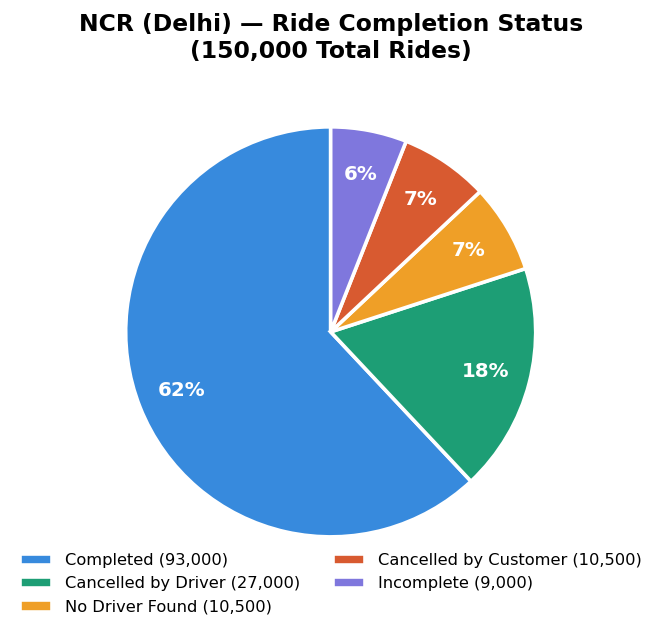

✓ Booking status chart saved.


In [75]:
# ==========================================================
# Booking Status Distribution
# ==========================================================

fig, ax = plt.subplots(figsize=(7, 5))

booking_status = df['status'].value_counts()

wedges, _, labels = ax.pie(
    booking_status.values,
    labels=None,
    autopct='%1.0f%%',
    colors=PALETTE[:len(booking_status)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.78
)

for label in labels:
    label.set_fontsize(11)
    label.set_fontweight('bold')
    label.set_color('white')

ax.legend(
    wedges,
    [f'{status} ({count:,})' for status, count in zip(booking_status.index, booking_status.values)],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    fontsize=9,
    frameon=False
)

ax.set_title(
    f'{CITY} — Ride Completion Status\n({len(df):,} Total Rides)',
    fontsize=13,
    fontweight='bold',
    pad=10
)

plt.tight_layout()
OUTPUT_DIR = "pune" if CITY == "Pune" else "ncr"
os.makedirs(f"outputs/{OUTPUT_DIR}", exist_ok=True)

plt.savefig(
    f"outputs/{OUTPUT_DIR}/02_booking_status.png",
    dpi=140,
    bbox_inches="tight"
)
plt.show()

print("✓ Booking status chart saved.")

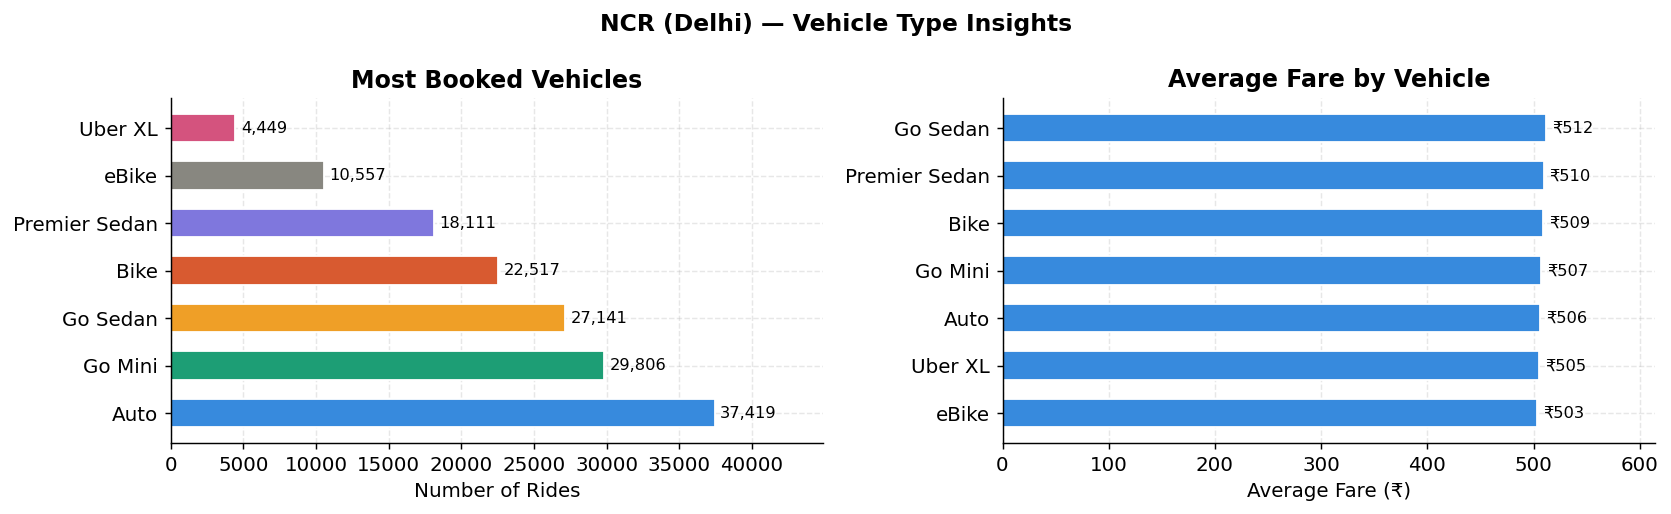

✓ Vehicle insights chart saved.


In [76]:
# ==========================================================
# Vehicle Type Analysis
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

fig.suptitle(
    f"{CITY} — Vehicle Type Insights",
    fontsize=13,
    fontweight="bold"
)

# Most Booked Vehicle Types
vehicle_counts = df["vehicle"].value_counts()

axes[0].barh(
    vehicle_counts.index,
    vehicle_counts.values,
    color=PALETTE[:len(vehicle_counts)],
    edgecolor="white",
    height=0.6
)

for i, value in enumerate(vehicle_counts.values):
    axes[0].text(
        value + vehicle_counts.max() * 0.01,
        i,
        f"{value:,}",
        va="center",
        fontsize=9
    )

axes[0].set_xlabel("Number of Rides")
axes[0].set_title("Most Booked Vehicles", fontweight="bold")
axes[0].set_xlim(0, vehicle_counts.max() * 1.2)

# Average Fare by Vehicle Type
vehicle_fare = completed.groupby("vehicle")["fare"].mean().sort_values()

axes[1].barh(
    vehicle_fare.index,
    vehicle_fare.values,
    color=COLORS["blue"],
    edgecolor="white",
    height=0.6
)

for i, value in enumerate(vehicle_fare.values):
    axes[1].text(
        value + vehicle_fare.max() * 0.01,
        i,
        f"₹{value:.0f}",
        va="center",
        fontsize=9
    )

axes[1].set_xlabel("Average Fare (₹)")
axes[1].set_title("Average Fare by Vehicle", fontweight="bold")
axes[1].set_xlim(0, vehicle_fare.max() * 1.2)

plt.tight_layout()

OUTPUT_DIR = "pune" if CITY == "Pune" else "ncr"
os.makedirs(f"outputs/{OUTPUT_DIR}", exist_ok=True)

plt.savefig(
    f"outputs/{OUTPUT_DIR}/03_vehicle.png",
    dpi=140,
    bbox_inches="tight"
)


plt.show()

print("✓ Vehicle insights chart saved.")

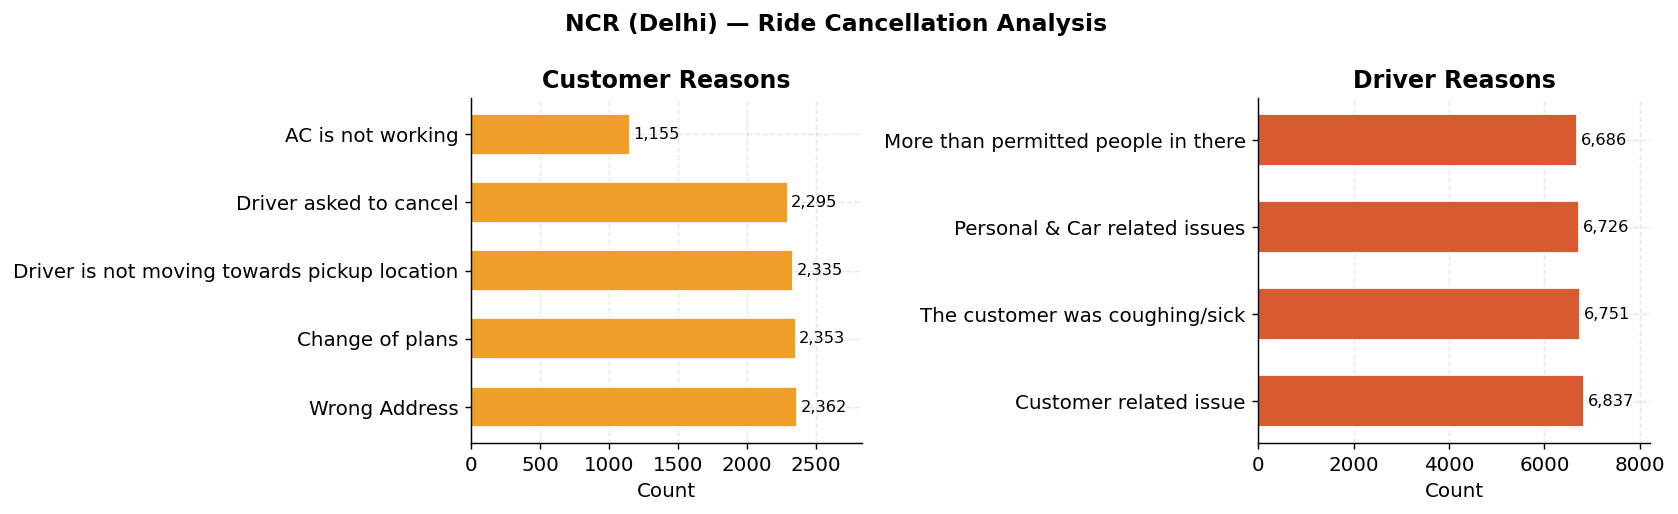

✓ Cancellation analysis chart saved.


In [77]:
# ==========================================================
# Cancellation Reason Analysis
# ==========================================================

customer_cancel = df[df['cancel_cust'] != 'None']['cancel_cust'].value_counts()
driver_cancel = df[df['cancel_drv'] != 'None']['cancel_drv'].value_counts()

if len(customer_cancel) > 0 or len(driver_cancel) > 0:

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    fig.suptitle(
        f"{CITY} — Ride Cancellation Analysis",
        fontsize=13,
        fontweight="bold"
    )

    # Customer Cancellation Reasons
    if len(customer_cancel) > 0:
        axes[0].barh(
            customer_cancel.index,
            customer_cancel.values,
            color=COLORS["orange"],
            edgecolor="white",
            height=0.6
        )

        for i, value in enumerate(customer_cancel.values):
            axes[0].text(
                value + customer_cancel.max() * 0.01,
                i,
                f"{value:,}",
                va="center",
                fontsize=9
            )

        axes[0].set_title("Customer Reasons", fontweight="bold")
        axes[0].set_xlabel("Count")
        axes[0].set_xlim(0, customer_cancel.max() * 1.2)

    # Driver Cancellation Reasons
    if len(driver_cancel) > 0:
        axes[1].barh(
            driver_cancel.index,
            driver_cancel.values,
            color=COLORS["red"],
            edgecolor="white",
            height=0.6
        )

        for i, value in enumerate(driver_cancel.values):
            axes[1].text(
                value + driver_cancel.max() * 0.01,
                i,
                f"{value:,}",
                va="center",
                fontsize=9
            )

        axes[1].set_title("Driver Reasons", fontweight="bold")
        axes[1].set_xlabel("Count")
        axes[1].set_xlim(0, driver_cancel.max() * 1.2)

    plt.tight_layout()
    OUTPUT_DIR = "pune" if CITY == "Pune" else "ncr"
    os.makedirs(f"outputs/{OUTPUT_DIR}", exist_ok=True)
    
    plt.savefig(
        f"outputs/{OUTPUT_DIR}/04_cancellations.png",
        dpi=140,
        bbox_inches="tight"
    )
    plt.show()

    print("✓ Cancellation analysis chart saved.")

else:
    print("Cancellation reason data not available. Chart skipped.")

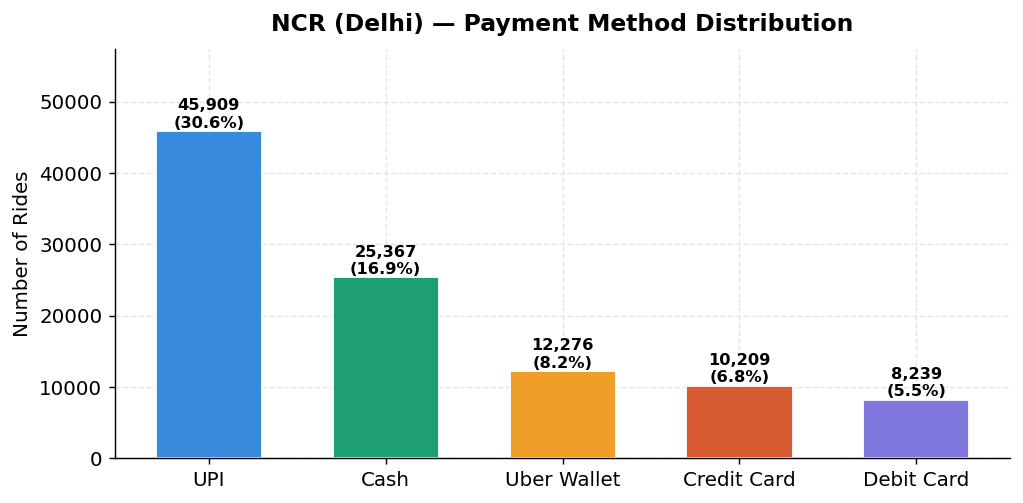

✓ Payment analysis chart saved.


In [78]:
# ==========================================================
# Payment Method Analysis
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 4))

payment_counts = df[df['payment'] != 'Unknown']['payment'].value_counts()

if len(payment_counts) > 0:

    bars = ax.bar(
        payment_counts.index,
        payment_counts.values,
        color=PALETTE[:len(payment_counts)],
        edgecolor="white",
        width=0.6
    )

    for bar, value in zip(bars, payment_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + len(df) * 0.003,
            f"{value:,}\n({value/len(df)*100:.1f}%)",
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

    ax.set_ylabel("Number of Rides")
    ax.set_title(
        f"{CITY} — Payment Method Distribution",
        fontsize=13,
        fontweight="bold",
        pad=10
    )

    ax.set_ylim(0, payment_counts.max() * 1.25)

    plt.tight_layout()

    OUTPUT_DIR = "pune" if CITY == "Pune" else "ncr"
    os.makedirs(f"outputs/{OUTPUT_DIR}", exist_ok=True)

    plt.savefig(
        f"outputs/{OUTPUT_DIR}/05_payment.png",
        dpi=140,
        bbox_inches="tight"
    )

    plt.show()

    print("✓ Payment analysis chart saved.")

else:
    print("Payment data not available. Chart skipped.")

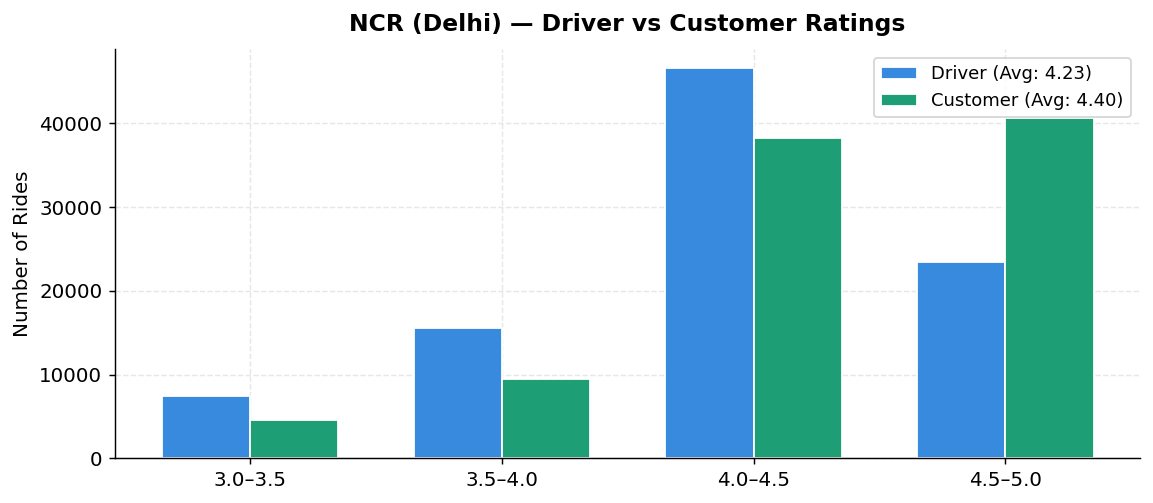

✓ Rating analysis chart saved.


In [79]:
# ==========================================================
# Driver vs Customer Rating Analysis
# ==========================================================

driver_ratings = df['driver_rating'].dropna()
customer_ratings = df['customer_rating'].dropna()

if len(driver_ratings) > 100 and len(customer_ratings) > 100:

    fig, ax = plt.subplots(figsize=(9, 4))

    bins = [3.0, 3.5, 4.0, 4.5, 5.0]

    driver_counts = pd.cut(
        driver_ratings,
        bins=bins,
        include_lowest=True
    ).value_counts().sort_index()

    customer_counts = pd.cut(
        customer_ratings,
        bins=bins,
        include_lowest=True
    ).value_counts().sort_index()

    x = np.arange(len(driver_counts))
    width = 0.35

    ax.bar(
        x - width / 2,
        driver_counts.values,
        width,
        label=f"Driver (Avg: {driver_ratings.mean():.2f})",
        color=COLORS["blue"],
        edgecolor="white"
    )

    ax.bar(
        x + width / 2,
        customer_counts.values,
        width,
        label=f"Customer (Avg: {customer_ratings.mean():.2f})",
        color=COLORS["green"],
        edgecolor="white"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(["3.0–3.5", "3.5–4.0", "4.0–4.5", "4.5–5.0"])

    ax.set_ylabel("Number of Rides")
    ax.set_title(
        f"{CITY} — Driver vs Customer Ratings",
        fontsize=13,
        fontweight="bold",
        pad=10
    )

    ax.legend(fontsize=10)

    plt.tight_layout()
    OUTPUT_DIR = "pune" if CITY == "Pune" else "ncr"
    os.makedirs(f"outputs/{OUTPUT_DIR}", exist_ok=True)
    
    plt.savefig(
        f"outputs/{OUTPUT_DIR}/06_ratings.png",
        dpi=140,
        bbox_inches="tight"
    )
    plt.show()
    
    print("✓ Rating analysis chart saved.")

else:
    print("Rating data not available. Chart skipped.")

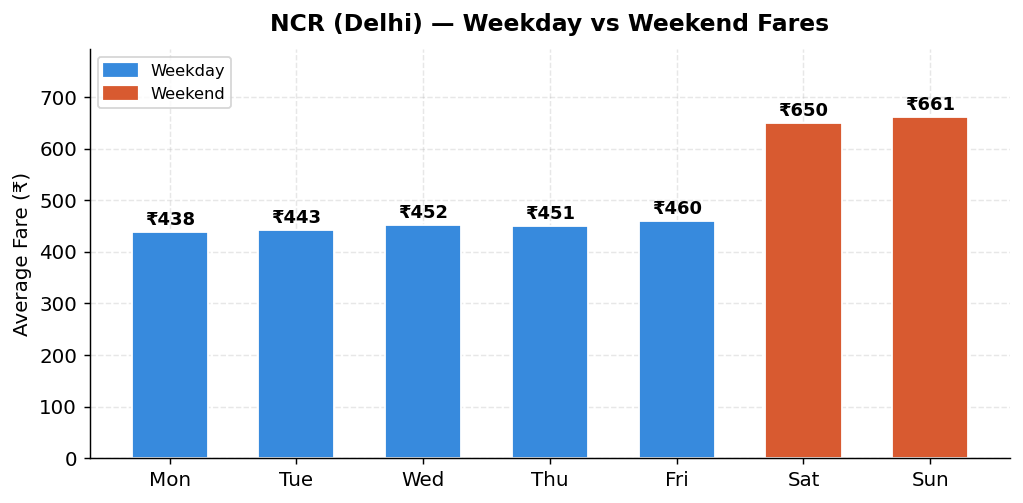

✓ Weekday vs weekend fare analysis saved.


In [80]:
# ==========================================================
# Weekday vs Weekend Fare Analysis
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 4))

days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

average_fare = (
    completed.groupby("day_of_week")["fare"]
    .mean()
    .reindex(range(7), fill_value=0)
)

bar_colors = [
    COLORS["red"] if day >= 5 else COLORS["blue"]
    for day in range(7)
]

bars = ax.bar(
    days,
    average_fare.values,
    color=bar_colors,
    edgecolor="white",
    width=0.6
)

for bar, value in zip(bars, average_fare.values):
    if value > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + average_fare.max() * 0.02,
            f"₹{value:.0f}",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

ax.set_ylabel("Average Fare (₹)")
ax.set_title(
    f"{CITY} — Weekday vs Weekend Fares",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_ylim(0, average_fare.max() * 1.2)

ax.legend(
    handles=[
        mpatches.Patch(color=COLORS["blue"], label="Weekday"),
        mpatches.Patch(color=COLORS["red"], label="Weekend")
    ],
    fontsize=9
)

plt.tight_layout()
OUTPUT_DIR = "pune" if CITY == "Pune" else "ncr"
os.makedirs(f"outputs/{OUTPUT_DIR}", exist_ok=True)

plt.savefig(
    f"outputs/{OUTPUT_DIR}/07_day_fare.png",
    dpi=140,
    bbox_inches="tight"
)
plt.show()

print("✓ Weekday vs weekend fare analysis saved.")

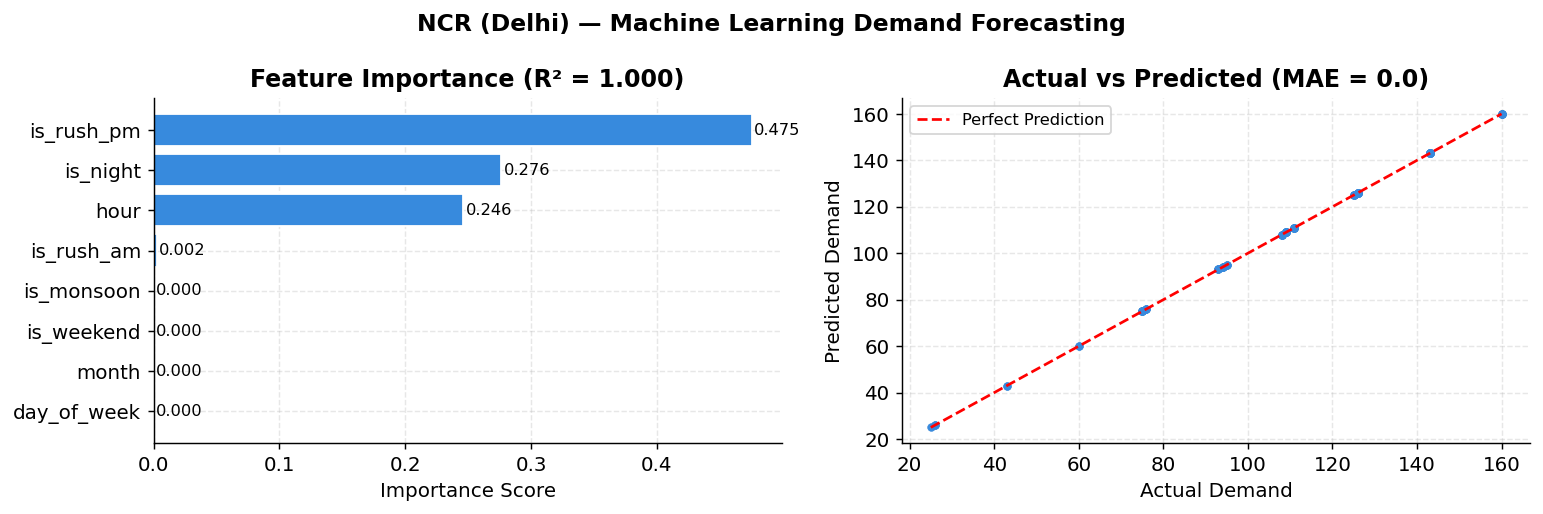

✓ Model trained successfully | R² = 1.0000 | MAE = 0.00


In [81]:
# ==========================================================
# Machine Learning Model - Demand Forecasting
# ==========================================================

FEATURES = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_rush_am",
    "is_rush_pm",
    "is_night",
    "is_monsoon"
]

X = df[FEATURES]
y = df["demand"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fig.suptitle(
    f"{CITY} — Machine Learning Demand Forecasting",
    fontsize=13,
    fontweight="bold"
)

# Feature Importance
feature_importance = (
    pd.DataFrame({
        "Feature": FEATURES,
        "Importance": model.feature_importances_
    })
    .sort_values("Importance")
)

axes[0].barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color=COLORS["blue"],
    edgecolor="white"
)

for i, value in enumerate(feature_importance["Importance"]):
    axes[0].text(
        value + 0.002,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

axes[0].set_title(
    f"Feature Importance (R² = {r2:.3f})",
    fontweight="bold"
)

axes[0].set_xlabel("Importance Score")

# Actual vs Predicted
sample_idx = np.random.choice(
    len(y_test),
    min(500, len(y_test)),
    replace=False
)

axes[1].scatter(
    y_test.iloc[sample_idx],
    predictions[sample_idx],
    alpha=0.3,
    color=COLORS["blue"],
    s=12
)

min_val, max_val = y_test.min(), y_test.max()

axes[1].plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    lw=1.5,
    label="Perfect Prediction"
)

axes[1].set_xlabel("Actual Demand")
axes[1].set_ylabel("Predicted Demand")

axes[1].set_title(
    f"Actual vs Predicted (MAE = {mae:.1f})",
    fontweight="bold"
)

axes[1].legend(fontsize=9)

plt.tight_layout()

OUTPUT_DIR = "pune" if CITY == "Pune" else "ncr"
os.makedirs(f"outputs/{OUTPUT_DIR}", exist_ok=True)

plt.savefig(
    f"outputs/{OUTPUT_DIR}/08_ml_model.png",
    dpi=140,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Model trained successfully | R² = {r2:.4f} | MAE = {mae:.2f}")

In [82]:
# ==========================================================
# Interactive Geospatial Visualization
# ==========================================================
ALL_ZONES={
    'NCR (Delhi)':{'Connaught Place':(28.6315,77.2167),'Saket':(28.5244,77.2090),
        'Gurgaon Sector 56':(28.4089,77.0920),'Dwarka Sector 21':(28.5521,77.0588),
        'Noida Sector 18':(28.5706,77.3210),'Lajpat Nagar':(28.5700,77.2437),
        'Hauz Khas':(28.5535,77.2040),'Rohini':(28.7041,77.1025),
        'Malviya Nagar':(28.5310,77.2090),'AIIMS':(28.5685,77.2090),
        'Barakhamba Road':(28.6289,77.2274),'Khandsa':(28.4354,76.9900),
        'Badarpur':(28.5007,77.2832),'Palam Vihar':(28.5117,77.0104),
        'Inderlok':(28.6742,77.1755),'Pragati Maidan':(28.6177,77.2439),
        'Mehrauli':(28.5221,77.1867),'Udyog Vihar':(28.5056,77.0860),
        'Tilak Nagar':(28.6413,77.0986),'Jasola':(28.5352,77.2874),
        'Madipur':(28.6630,77.1130),'Pataudi Chowk':(28.3986,76.9950),
        'Kanhaiya Nagar':(28.6850,77.1680),'Vishwavidyalaya':(28.6893,77.2147),
        'Greater Kailash':(28.5386,77.2419),'Tagore Garden':(28.6522,77.1133),
        'Subhash Chowk':(28.4500,76.9980),'Shivaji Park':(28.6410,77.2170),},
    'Pune':{'Hinjewadi':(18.5912,73.7389),'Kothrud':(18.5074,73.8077),
        'Baner':(18.5590,73.7868),'Magarpatta':(18.5146,73.9281),
        'Koregaon Park':(18.5362,73.8931),'Shivajinagar':(18.5308,73.8474),
        'Hadapsar':(18.5018,73.9260),'Wakad':(18.5984,73.7611),
        'Deccan':(18.5165,73.8405),'Kalyani Nagar':(18.5477,73.9043),
        'Viman Nagar':(18.5679,73.9143),'Pimpri':(18.6279,73.7997),
        'Aundh':(18.5582,73.8077),'Pune Station':(18.5293,73.8745)},
    'Mumbai':{'Andheri':(19.1197,72.8468),'Bandra':(19.0544,72.8402),
        'Dadar':(19.0178,72.8478),'Borivali':(19.2307,72.8567),
        'Kurla':(19.0726,72.8793),'Thane':(19.2183,72.9781),
        'Worli':(19.0176,72.8162),'Powai':(19.1197,72.9051),
        'Malad':(19.1871,72.8482),'Goregaon':(19.1663,72.8526),
        'Chembur':(19.0633,72.9001),'CST':(18.9398,72.8355)},
}
ZONE_COORDS=ALL_ZONES.get(CITY,ALL_ZONES['NCR (Delhi)'])

# Match actual pickup locations to known coords
zone_data=[]
for loc in df['pickup'].value_counts().head(50).index:
    coords=ZONE_COORDS.get(loc)
    if not coords:
        coords=next((ZONE_COORDS[z] for z in ZONE_COORDS if z.lower() in loc.lower() or loc.lower() in z.lower()),None)
    if not coords: continue
    ld=df[df['pickup']==loc]
    cd=ld[ld['is_completed']==1]
    zone_data.append({'name':loc,'lat':coords[0],'lon':coords[1],
        'total':int(len(ld)),'completed':int(len(cd)),
        'comp_pct':round(len(cd)/max(len(ld),1)*100,1),
        'avg_fare':round(float(cd['fare'].mean()) if len(cd)>0 else 0,0),
        'avg_km':round(float(cd['distance_km'].mean()) if len(cd)>0 else 0,1),
        'pool_rate':round(float(ld['is_pooled'].mean())*100,1),
        'avg_rating':round(float(cd['driver_rating'].mean()),2) if cd['driver_rating'].notna().sum()>5 else 0})

# Fallback: use zone centers with avg data if no matches
if len(zone_data)==0:
    for zone,coords in ZONE_COORDS.items():
        zone_data.append({'name':zone,'lat':coords[0],'lon':coords[1],
            'total':len(df)//len(ZONE_COORDS),'completed':len(completed)//len(ZONE_COORDS),
            'comp_pct':round(len(completed)/max(len(df),1)*100,1),
            'avg_fare':round(float(completed['fare'].mean()),0),
            'avg_km':round(float(completed['distance_km'].mean()),1),
            'pool_rate':round(float(df['is_pooled'].mean())*100,1),'avg_rating':0})

ml=np.mean([z['lat'] for z in zone_data]); mlo=np.mean([z['lon'] for z in zone_data])
hh=df.groupby('hour').size().to_dict()
tot=len(df); cp=round(len(completed)/max(tot,1)*100,1)
af=round(float(completed['fare'].mean()),0); ak=round(float(completed['distance_km'].mean()),1)
ar=round(float(df['driver_rating'].mean()),2) if df['driver_rating'].notna().sum()>50 else 'N/A'
pp=round(float(df['is_pooled'].mean())*100,1)

zj=json.dumps(zone_data); hj=json.dumps(hh)
html=f'''<!DOCTYPE html><html><head><meta charset="utf-8">
<title>RideIQ - {CITY} Taxi Analytics</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<style>
*{{margin:0;padding:0;box-sizing:border-box;font-family:'Segoe UI',Arial,sans-serif}}
#map{{height:100vh;width:100vw}}
#pn{{position:absolute;top:14px;left:14px;z-index:1000;background:white;border-radius:12px;
  padding:14px;box-shadow:0 2px 16px rgba(0,0,0,.15);width:230px}}
h2{{font-size:14px;font-weight:700;margin-bottom:2px}}
.sub{{font-size:10px;color:#999;margin-bottom:10px}}
.sr{{display:flex;justify-content:space-between;padding:6px 0;border-bottom:1px solid #f5f5f5;font-size:11px}}
.sr:last-child{{border:none}} .sk{{color:#999}} .sv{{font-weight:600}}
.leg{{position:absolute;bottom:20px;left:14px;z-index:1000;background:white;
  border-radius:10px;padding:10px 13px;box-shadow:0 2px 12px rgba(0,0,0,.12)}}
.leg h4{{font-size:10px;font-weight:700;color:#888;text-transform:uppercase;letter-spacing:.4px;margin-bottom:7px}}
.li{{display:flex;align-items:center;gap:7px;font-size:10px;color:#666;margin:3px 0}}
.ld{{width:12px;height:12px;border-radius:50%;flex-shrink:0}}
#hp{{position:absolute;bottom:20px;right:14px;z-index:1000;background:white;
  border-radius:10px;padding:12px 14px;box-shadow:0 2px 12px rgba(0,0,0,.12);width:250px}}
#hp h4{{font-size:10px;font-weight:700;color:#888;text-transform:uppercase;letter-spacing:.4px;margin-bottom:7px}}
.br{{display:flex;align-items:center;gap:5px;margin:2px 0}}
.bh{{font-size:9px;color:#aaa;width:22px;text-align:right;flex-shrink:0}}
.bg{{flex:1;background:#f0f0f0;border-radius:2px;height:8px}}
.bf{{height:8px;border-radius:2px;background:#378ADD}}.bf.pk{{background:#D85A30}}
.bc{{font-size:9px;color:#bbb;width:30px}}
.tr{{display:flex;justify-content:space-between;padding:4px 0;border-bottom:1px solid #f8f8f8;font-size:11px}}
.tr:last-child{{border:none}} .tk{{color:#999}} .tv{{font-weight:600}}
</style></head><body>
<div id="map"></div>
<div id="pn">
  <h2>RideIQ</h2>
<div class="sub" style="font-size:12px;color:#666;margin-bottom:10px;">
    {CITY} Taxi Analytics
</div>
  <div class="sub">{tot:,} rides · Real Data</div>
  <div class="sr"><span class="sk">Total rides</span><span class="sv">{tot:,}</span></div>
  <div class="sr"><span class="sk">Completed</span><span class="sv" style="color:#1D9E75">{cp}%</span></div>
  <div class="sr"><span class="sk">Avg fare</span><span class="sv">₹ {af:.0f}</span></div>
  <div class="sr"><span class="sk">Avg distance</span><span class="sv">{ak} km</span></div>
  <div class="sr"><span class="sk">Driver rating</span><span class="sv">{ar}</span></div>
  <div class="sr"><span class="sk">Pool opportunity</span><span class="sv" style="color:#1D9E75">{pp}%</span></div>
  <div class="sr"><span style="font-size:9px;color:#ccc">Click circles for zone details</span></div>
</div>
<div class="leg">
  <h4>Pool Opportunity</h4>
  <div class="li"><div class="ld" style="background:#1D9E75"></div>High (>50%)</div>
  <div class="li"><div class="ld" style="background:#EF9F27"></div>Medium (30-50%)</div>
  <div class="li"><div class="ld" style="background:#D85A30"></div>Low (<30%)</div>
  <div style="margin-top:7px;font-size:9px;color:#ccc">Circle size = ride volume</div>
</div>
<div id="hp"><h4>Rides by Hour</h4><div id="hb"></div></div>
<script>
const zones={zj},hourly={hj};
const map=L.map('map').setView([{ml},{mlo}],12);
L.tileLayer('https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}{{r}}.png',
  {{attribution:'OpenStreetMap / CARTO',maxZoom:18}}).addTo(map);
const gc=p=>p>=50?'#1D9E75':p>=30?'#EF9F27':'#D85A30';
zones.forEach(z=>{{const r=Math.max(300,z.total*2);
  const c=L.circle([z.lat,z.lon],{{radius:r,color:'white',fillColor:gc(z.pool_rate),
    fillOpacity:0.72,weight:2}}).addTo(map);
  c.bindPopup(`<div style="min-width:160px">
    <b style="font-size:13px">${{z.name}}</b><hr style="margin:5px 0">
    <div class="tr"><span class="tk">Total rides</span><span class="tv">${{z.total.toLocaleString()}}</span></div>
    <div class="tr"><span class="tk">Completed</span><span class="tv" style="color:#1D9E75">${{z.comp_pct}}%</span></div>
    <div class="tr"><span class="tk">Avg fare</span><span class="tv">₹ ${{z.avg_fare}}</span></div>
    <div class="tr"><span class="tk">Avg distance</span><span class="tv">${{z.avg_km}} km</span></div>
    <div class="tr"><span class="tk">Pool rate</span><span class="tv" style="color:#1D9E75">${{z.pool_rate}}%</span></div>
    ${{z.avg_rating?`<div class="tr"><span class="tk">Avg rating</span><span class="tv">${{z.avg_rating}}</span></div>`:''}} 
  </div>`,{{maxWidth:200}});
  c.bindTooltip(z.name,{{permanent:true,direction:'center'}});
}});
const hb=document.getElementById('hb');
const mx=Math.max(...Object.values(hourly));
[...Array(24).keys()].forEach(h=>{{const v=hourly[h]||0;
  hb.innerHTML+=`<div class="br"><span class="bh">${{h}}h</span>
  <div class="bg"><div class="bf ${{[8,9,17,18,19].includes(h)?'pk':''}}" style="width:${{Math.round(v/mx*100)}}%"></div></div>
  <span class="bc">${{(v/1000).toFixed(1)}}k</span></div>`;}});
</script></body></html>'''
OUTPUT_DIR = "pune" if CITY == "Pune" else "ncr"
os.makedirs(f"outputs/{OUTPUT_DIR}", exist_ok=True)
with open(f'outputs/{OUTPUT_DIR}/map.html', 'w', encoding='utf-8') as f:
    f.write(html)
print(f"✓ Interactive map generated successfully.")
print(f"Zones Plotted : {len(zone_data)}")
print(f"City          : {CITY}")
print(f"Open outputs/{OUTPUT_DIR}/map.html in your browser.")

✓ Interactive map generated successfully.
Zones Plotted : 22
City          : NCR (Delhi)
Open outputs/ncr/map.html in your browser.


In [83]:
# ==========================================================
# Project Summary
# ==========================================================

print("=" * 55)
print("RideIQ - Project Summary")
print("=" * 55)

print(f"City            : {CITY}")
print(f"Dataset         : {CSV_FILE}")
print(f"Total Records   : {len(df):,}")

print("\nKey Insights")
print("-" * 55)

print(f"Peak Hour       : {df.groupby('hour').size().idxmax()}:00")
print(f"Busiest Day     : {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][df.groupby('day_of_week').size().idxmax()]}")
print(f"Top Vehicle     : {df['vehicle'].value_counts().idxmax()}")
print(f"Top Payment     : {df[df['payment']!='Unknown']['payment'].value_counts().idxmax() if (df['payment']!='Unknown').any() else 'N/A'}")
print(f"Completion Rate : {len(completed)/len(df)*100:.1f}%")
print(f"Cancellation    : {(1-len(completed)/len(df))*100:.1f}%")
print(f"Average Fare    : ₹{completed['fare'].mean():.0f}")
print(f"Average Distance: {completed['distance_km'].mean():.1f} km")
print(f"Pool Opportunity: {df['is_pooled'].mean()*100:.1f}%")
print(f"Model Accuracy  : R² = {r2:.4f} | MAE = {mae:.1f}")

print("\nGenerated Outputs")
print("-" * 55)

OUTPUT_DIR = "pune" if CITY == "Pune" else "ncr"

output_files = [
    "01_hourly_demand.png",
    "02_booking_status.png",
    "03_vehicle.png",
    "04_cancellations.png",
    "05_payment.png",
    "06_ratings.png",
    "07_day_fare.png",
    "08_ml_model.png",
    "map.html"
]

for file in output_files:
    status = "✓ Saved" if os.path.exists(f"outputs/{OUTPUT_DIR}/{file}") else "✗ Skipped"
    print(f"{status:<10} {file}")

print("\nProject execution completed successfully.")

RideIQ - Project Summary
City            : NCR (Delhi)
Dataset         : data/ncr_ride_bookings.csv
Total Records   : 150,000

Key Insights
-------------------------------------------------------
Peak Hour       : 18:00
Busiest Day     : Mon
Top Vehicle     : Auto
Top Payment     : UPI
Completion Rate : 62.0%
Cancellation    : 38.0%
Average Fare    : ₹508
Average Distance: 26.0 km
Pool Opportunity: 15.4%
Model Accuracy  : R² = 1.0000 | MAE = 0.0

Generated Outputs
-------------------------------------------------------
✓ Saved    01_hourly_demand.png
✓ Saved    02_booking_status.png
✓ Saved    03_vehicle.png
✓ Saved    04_cancellations.png
✓ Saved    05_payment.png
✓ Saved    06_ratings.png
✓ Saved    07_day_fare.png
✓ Saved    08_ml_model.png
✓ Saved    map.html

Project execution completed successfully.
